IMPORTING NECESSARY LIBRARIES

In [ ]:
# Installing qutip for Wigner function calculation
!pip install qutip --quiet

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D
import qutip as qt

print("All libraries imported successfully!")

All libraries imported successfully!


**DEFINING NECESSARY PARAMETERS**

In [ ]:
# Squeezing parameters (measured at Alice)
squeezing_dB      = -2.4
antisqueezing_dB  = 14.2

#conversion into variance
V_sq    = 10 ** (squeezing_dB    / 10)
V_antisq = 10 ** (antisqueezing_dB / 10)


#Transmission range
T = np.linspace(0, 1, 300)
#Natural channel transmission range
T_nat_min = 0.50
T_nat_max = 0.64


#Squeezing values reported after channel
sq_avg_dB      = -0.95
sq_postsel_dB  = -1.08

#Quantum state tomography parameters
T_selected    = 0.552
purity        = 0.237


#(beam-splitter loss model)
V_sq_out    = T_selected * V_sq    + (1 - T_selected)
V_antisq_out = T_selected * V_antisq + (1 - T_selected)

In [ ]:
print(f"Squeezed variance at Alice        : {V_sq:.4f}  ({squeezing_dB} dB)")
print(f"Antisqueezed variance at Alice    : {V_antisq:.2f}  ({antisqueezing_dB} dB)")
print(f"Squeezed variance after channel   : {V_sq_out:.4f}")
print(f"Antisqueezed variance after channel: {V_antisq_out:.2f}")
print(f"Purity of reconstructed state     : {purity}")

Squeezed variance at Alice        : 0.5754  (-2.4 dB)
Antisqueezed variance at Alice    : 26.30  (14.2 dB)
Squeezed variance after channel   : 0.7656
Antisqueezed variance after channel: 14.97
Purity of reconstructed state     : 0.237


In [ ]:
S0_linear = T

# Squeezed signal: quadratic scaling


S_sq_quad = T**2 * V_sq + T * (1 - T)

np.random.seed(42)
T_data      = np.linspace(0.02, 1.0, 80)
noise_S0    = np.random.normal(0, 0.01, len(T_data))
noise_sq    = np.random.normal(0, 0.005, len(T_data))

S0_data  = T_data + noise_S0
Ssq_data = T_data**2 * V_sq + T_data * (1 - T_data) + noise_sq



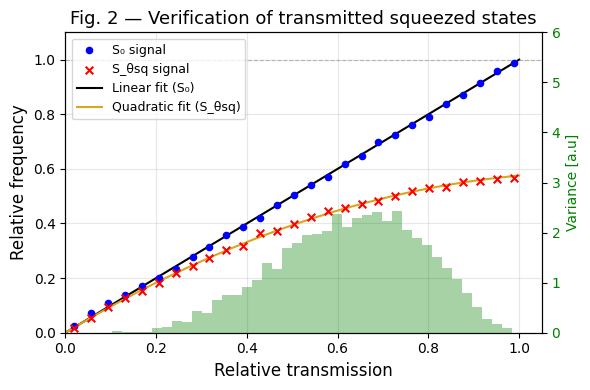

In [ ]:
#Plot
fig, ax1 = plt.subplots(figsize=(6, 4))
#Transmission histogram
ax2 = ax1.twinx()
T_hist = np.random.beta(5, 3, 5000)   #simulating fading
ax2.hist(T_hist, bins=40, color='green', alpha=0.35, density=True, label='Transmission histogram')
ax2.set_ylabel('Variance [a.u]', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.set_ylim(0, 6)

# Data points—every 3rd point shown
ax1.scatter(T_data[::3], S0_data[::3],  color='blue',   marker='o', s=20, label='S₀ signal', zorder=5)
ax1.scatter(T_data[::3], Ssq_data[::3], color='red',    marker='x', s=30, label='S_θsq signal', zorder=5)

#Fit lines
ax1.plot(T, S0_linear, 'k-',      linewidth=1.5, label='Linear fit (S₀)')
ax1.plot(T, S_sq_quad, color='goldenrod', linewidth=1.5, label='Quadratic fit (S_θsq)')

ax1.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.set_xlabel('Relative transmission', fontsize=12)
ax1.set_ylabel('Relative frequency', fontsize=12)
ax1.set_title('Fig. 2 — Verification of transmitted squeezed states', fontsize=13)
ax1.set_xlim(0, 1.05)
ax1.set_ylim(0, 1.1)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('variance_vs_transmission.png', dpi=150, bbox_inches='tight')
plt.show()


**Transmission Statistics of Atmospheric Channel**

In [ ]:
#Simulating natural transmission statistics (log-normal fading channel)
np.random.seed(7)
mu_T    = 0.572  #mean transmission ~57%
sigma_T = 0.022    #narrow spread(turbulence)
T_natural = np.random.normal(mu_T, sigma_T, 100000)
T_natural = T_natural[(T_natural >= 0.50) & (T_natural <= 0.64)]

#Squeezing variance as function of transmission
T_range = np.linspace(0.50, 0.64, 300)

#Shot noise level
shot_noise_level = np.ones_like(T_range)

#Squeezed signal variance (quadratic model)
S_sq_nat = T_range**2 * V_sq + T_range * (1 - T_range)

#Convert back to dB relative to shot noise for display
#Normalize: S_sq / shot_noise_at_T
S0_at_T      = T_range          #shot noise variance scales linearly
ratio        = S_sq_nat / S0_at_T
squeezing_at_T_dB = 10 * np.log10(ratio)

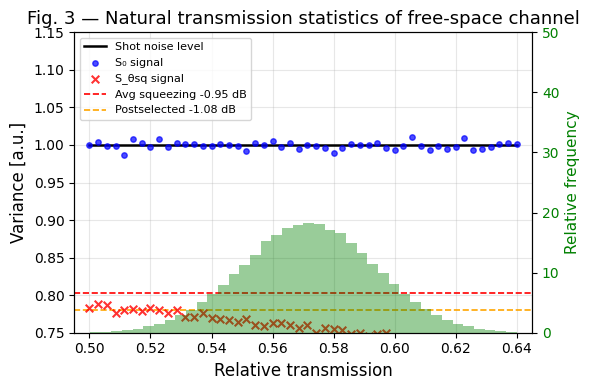

Fig. 3 saved.


In [ ]:
#Plot
fig, ax1 = plt.subplots(figsize=(6, 4))
ax2 = ax1.twinx()

ax2.hist(T_natural, bins=40, color='green', alpha=0.40, density=True, label='Transmission histogram')
ax2.set_ylabel('Relative frequency', color='green', fontsize=11)
ax2.tick_params(axis='y', labelcolor='green')
ax2.set_ylim(0, 50)

# Shot noise line (black,flat at normalized value)
ax1.plot(T_range, shot_noise_level, 'k-', linewidth=1.8, label='Shot noise level')

# S0 signal
T_pts = np.linspace(0.50, 0.64, 50)
S0_pts = 1.0 + np.random.normal(0, 0.005, 50)
ax1.scatter(T_pts, S0_pts, color='blue', marker='o', s=15, alpha=0.7, label='S₀ signal', zorder=5)

# Squeezed signal
S_sq_pts = T_pts**2 * V_sq / T_pts + (1 - T_pts) + np.random.normal(0, 0.003, 50)
ax1.scatter(T_pts, S_sq_pts, color='red', marker='x', s=30, alpha=0.8, label='S_θsq signal', zorder=5)

# Horizontal lines for squeezing values
V_avg     = 10 ** (sq_avg_dB / 10)
V_postsel = 10 ** (sq_postsel_dB / 10)
ax1.axhline(y=V_avg,     color='red',    linestyle='--', linewidth=1.2,
            label=f'Avg squeezing {sq_avg_dB} dB')
ax1.axhline(y=V_postsel, color='orange', linestyle='--', linewidth=1.2,
            label=f'Postselected {sq_postsel_dB} dB')

ax1.set_xlabel('Relative transmission', fontsize=12)
ax1.set_ylabel('Variance [a.u.]', fontsize=12)
ax1.set_title('Fig. 3 — Natural transmission statistics of free-space channel', fontsize=13)
ax1.set_xlim(0.495, 0.645)
ax1.set_ylim(0.75, 1.15)
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig3_natural_transmission.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig. 3 saved.")

### Wigner Function Reconstruction (Gaussian Model)

We construct the Wigner function of the transmitted quantum state by modeling it as a Gaussian state in phase space.

For a Gaussian state, the Wigner function is given by:

$$
W(x, y) = \frac{1}{\pi \sqrt{\det(V)}} \exp\left(-\frac{1}{2}
\begin{bmatrix} x & y \end{bmatrix}
V^{-1}
\begin{bmatrix} x \\ y \end{bmatrix}
\right)
$$

where $V$ is the covariance matrix of the state.

---

### Modeling Atmospheric Loss

After transmission through the atmospheric channel (transmission $T = 0.552$), the quadrature variances evolve according to a beam-splitter loss model:

$$
V_x = T \cdot V_{\text{sq}} + (1 - T)
$$

$$
V_y = T \cdot V_{\text{antisq}} + (1 - T)
$$

This accounts for mixing with vacuum noise due to losses.

---

### Matching Experimental Purity

The purity of a Gaussian state is given by:

$$
p = \frac{1}{2 \sqrt{\det(V)}}
$$

To match the experimentally reported purity ($p = 0.237$), we enforce:

$$
\det(V) = \frac{1}{4p^2}
\quad \Rightarrow \quad
\sigma_x \cdot \sigma_y = \frac{1}{2p}
$$

The variances are scaled accordingly while preserving the squeezing ratio.

---

### Final Goal

Using these parameters, we construct the Wigner function on a 2D grid and visualize:

- 3D phase-space distribution  
- 2D contour plot  
- Comparison with vacuum state  

This allows us to analyze how squeezing is preserved after atmospheric transmission.

sigma_x (squeezed)     = 0.3285
sigma_y (antisqueezed) = 6.4219
Computed purity        = 0.344  (paper reports: 0.237)
Squeezing ratio        = -12.91 dB


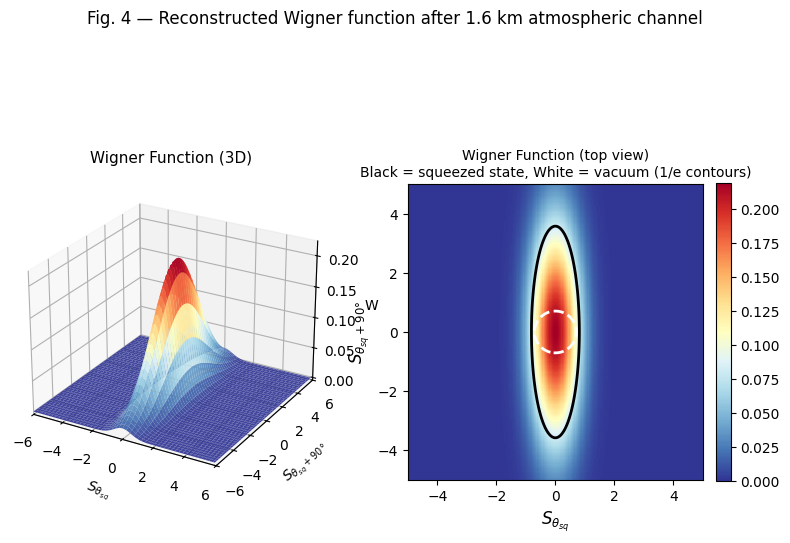

In [ ]:
target_purity = 0.237
target_product = 1.0 / (2.0 * target_purity)


T_sel = 0.552
V_x_raw = T_sel * V_sq    + (1 - T_sel)       # squeezed quadrature
V_y_raw = T_sel * V_antisq + (1 - T_sel)  # antisqueezed quadrature


k = np.sqrt(target_product / (V_x_raw * V_y_raw))
sigma_x = k * V_x_raw   #final squeezed variance
sigma_y = k * V_y_raw        #final antisqueezed variance

computed_purity = 1.0 / (2.0 * np.sqrt(sigma_x * sigma_y))
print(f"sigma_x (squeezed)     = {sigma_x:.4f}")
print(f"sigma_y (antisqueezed) = {sigma_y:.4f}")
print(f"Computed purity        = {computed_purity:.3f}  (paper reports: 0.237)")
print(f"Squeezing ratio        = {10*np.log10(sigma_x/sigma_y):.2f} dB")

xvec = np.linspace(-6, 6, 300)
X, Y = np.meshgrid(xvec, xvec)

# Gaussian Wigner function
W = (1.0 / (np.pi * np.sqrt(sigma_x * sigma_y))) * \
    np.exp(-0.5 * (X**2 / sigma_x + Y**2 / sigma_y))

sigma_vac = 0.5
W_vac = (1.0 / (np.pi * sigma_vac)) * \
        np.exp(-(X**2 + Y**2) / sigma_vac)

W_max_sq  = np.max(W)
W_max_vac = np.max(W_vac)

#3D surface + 2D top view

fig = plt.figure(figsize=(8, 6))

# 3D surface
ax3d = fig.add_subplot(121, projection='3d')


# Downsample grid for 3D rendering speed
step = 3
ax3d.plot_surface(X[::step, ::step], Y[::step, ::step], W[::step, ::step],
                  cmap='RdYlBu_r', linewidth=0, antialiased=True, alpha=0.92)
ax3d.set_xlabel('$S_{\\theta_{sq}}$',     fontsize=10, labelpad=5)
ax3d.set_ylabel('$S_{\\theta_{sq}+90°}$', fontsize=10, labelpad=5)
ax3d.set_zlabel('W', fontsize=10)
ax3d.set_title('Wigner Function (3D)', fontsize=11)
ax3d.set_xlim(-6, 6)
ax3d.set_ylim(-6, 6)
ax3d.view_init(elev=25, azim=-60)

#2D top view with 1/e contours
ax2d = fig.add_subplot(122)
im = ax2d.pcolormesh(X, Y, W, cmap='RdYlBu_r', shading='auto')
plt.colorbar(im, ax=ax2d, fraction=0.046, pad=0.04)


ax2d.contour(X, Y, W,     levels=[W_max_sq  / np.e], colors='black', linewidths=2.0)



ax2d.contour(X, Y, W_vac, levels=[W_max_vac / np.e], colors='white', linewidths=2.0,
             linestyles='--')

ax2d.set_xlabel('$S_{\\theta_{sq}}$',     fontsize=12)
ax2d.set_ylabel('$S_{\\theta_{sq}+90°}$', fontsize=12)
ax2d.set_title('Wigner Function (top view)\nBlack = squeezed state, White = vacuum (1/e contours)',
               fontsize=10)
ax2d.set_xlim(-5, 5)
ax2d.set_ylim(-5, 5)
ax2d.set_aspect('equal')

fig.suptitle('Fig. 4 — Reconstructed Wigner function after 1.6 km atmospheric channel',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig4_wigner_function.png', dpi=150, bbox_inches='tight')
plt.show()
